# ServiceHive assignment by Aman Mani tripathi

## from all machine learning model best model is GradientBoostingClassifier because it not overfit on training or testing data 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [2]:
# load dataset
df = pd.read_excel("fraud_data.xlsx")

In [3]:
# look top 5 rows
df.head()

,TransactionID,Amount,Time,Location,MerchantCategory,CardHolderAge,IsFraud
0,1,375.17,47605,Houston,Travel,18.0,0
1,2,950.76,38088,Los Angeles,Electronics,28.0,0
2,3,732.26,78752,Miami,Travel,20.0,0
3,4,599.06,55284,New York,Groceries,69.0,0
4,5,156.86,57043,New York,Groceries,79.0,0


## Exploratory Data Analysis ✅

In [4]:
# look the shape of dataset
df.shape

(500, 7)

In [5]:
# fill the null values 
    # Amount feature fill with mean of the Amount feature
    # Location feature fill with mode of the Location Feature
    # CardHolderAge feature fill with mean of the CardHolderAge feature

df["Amount"] = df["Amount"].fillna(df["Amount"].mean())
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
df["CardHolderAge"] = df["CardHolderAge"].fillna(df["CardHolderAge"].mean())

In [6]:
# check the null values of dataset
df.isnull().sum()

TransactionID       0
Amount              0
Time                0
Location            0
MerchantCategory    0
CardHolderAge       0
IsFraud             0
dtype: int64

In [7]:
# check the all information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     500 non-null    int64  
 1   Amount            500 non-null    float64
 2   Time              500 non-null    int64  
 3   Location          500 non-null    object 
 4   MerchantCategory  500 non-null    object 
 5   CardHolderAge     500 non-null    float64
 6   IsFraud           500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [8]:
## Drop the TransactionID feature 
df.drop(columns = ["TransactionID"],inplace = True)

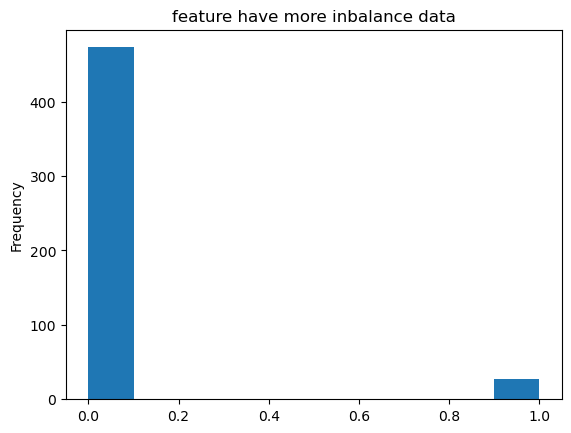

In [101]:
# In "IsFraud" feature have more inbalance data 
df["IsFraud"].plot(kind = "hist")
plt.title("feature have more inbalance data")
plt.show()

In [10]:
df["Time"].max()

86066

In [11]:
df["Time"].min()

55

In [12]:
# check the unique values of Location feature
df["Location"].unique()

array(['Houston', 'Los Angeles', 'Miami', 'New York', 'Chicago'],
      dtype=object)

In [13]:
# check the unique values of CardHolderAge feature
df["CardHolderAge"].unique()

array([ 18.        ,  28.        ,  20.        ,  69.        ,
        79.        ,  40.        ,  43.        ,  21.        ,
        35.        ,  72.        ,  23.        ,  52.        ,
        39.        ,  47.51890756,  32.        ,  77.        ,
        54.        ,  59.        ,  29.        ,  64.        ,
        66.        ,  55.        ,  62.        ,  47.        ,
        41.        ,  31.        ,  33.        ,  24.        ,
        26.        ,  19.        ,  44.        ,  37.        ,
        27.        ,  42.        ,  78.        ,  71.        ,
        50.        ,  53.        ,  48.        ,  63.        ,
        58.        ,  30.        ,  70.        ,  51.        ,
        25.        ,  49.        ,  46.        ,  60.        ,
        36.        ,  68.        ,  22.        ,  67.        ,
        73.        ,  38.        ,  45.        ,  56.        ,
        57.        ,  34.        ,  75.        , 120.        ,
         5.        ,  65.        ,  76.        ,  61.  

In [14]:
# check the unique values of MerchantCategory feature
df["MerchantCategory"].unique()

array(['Travel', 'Electronics', 'Groceries', 'Clothing', 'Entertainment'],
      dtype=object)

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


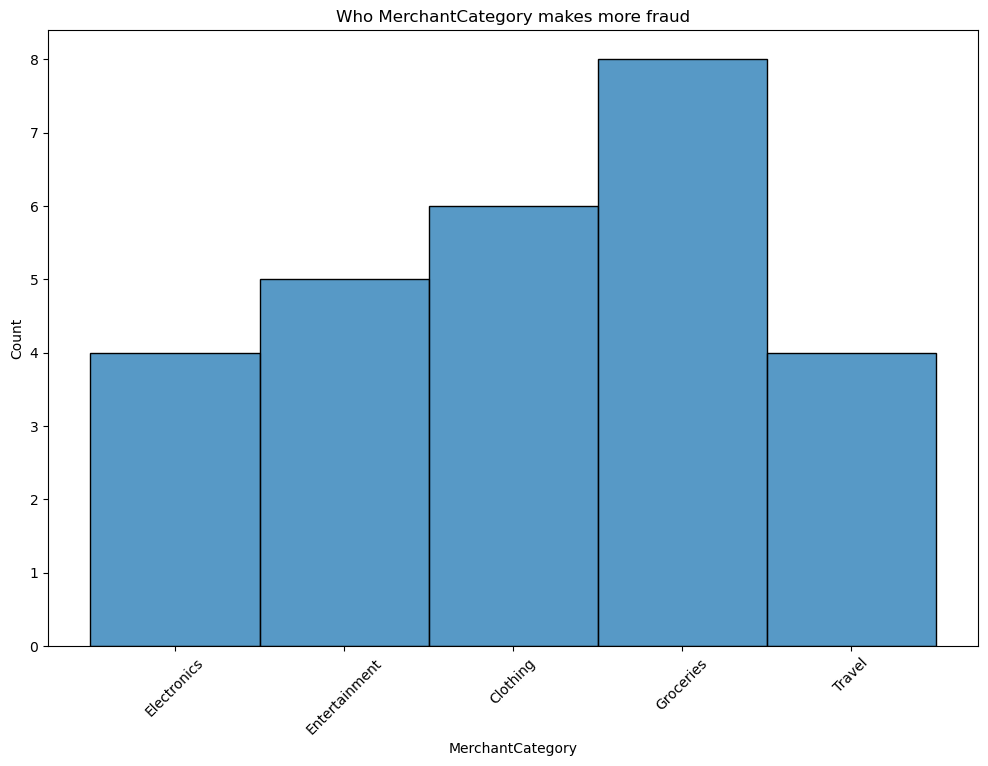

In [98]:
# It check the who MerchantCategory makes more fraud
plt.figure(figsize = (12,8))
sns.histplot(df[df["IsFraud"] == 1]["MerchantCategory"])
plt.title("Who MerchantCategory makes more fraud")
plt.xticks(rotation = 45)
plt.show()

## This graph show the Groceries merchant are max making Fraud

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


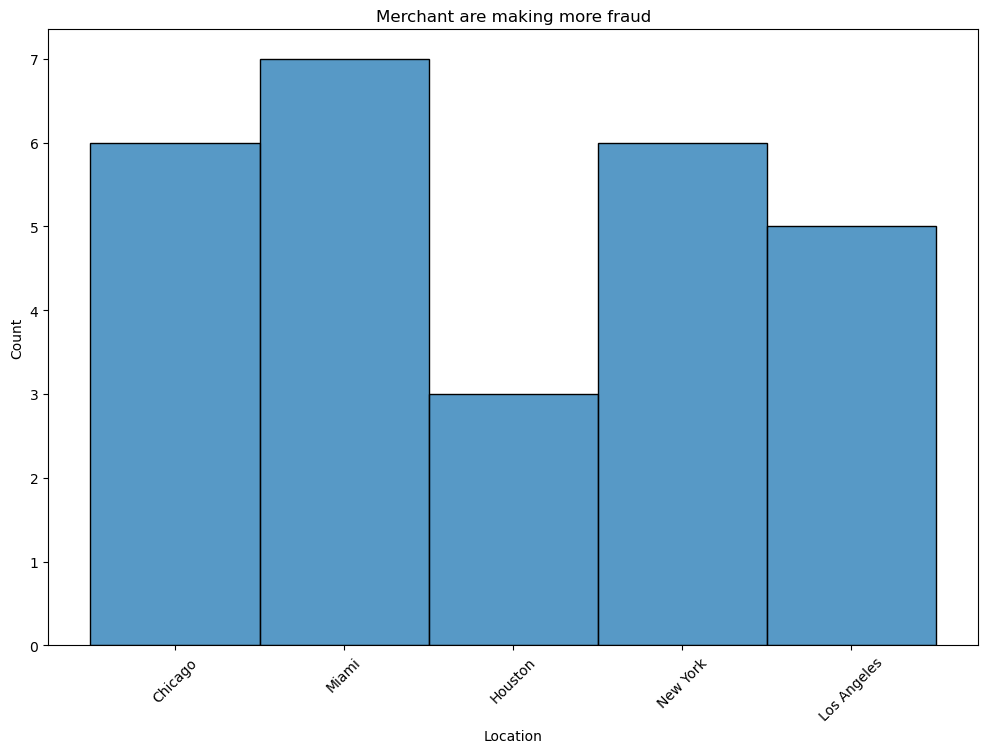

In [97]:
# This graph show the Location " Miami " merchant are making more fraud
plt.figure(figsize = (12,8))
sns.histplot(df[df["IsFraud"] == 1]["Location"])
plt.title("Merchant are making more fraud")
plt.xticks(rotation = 45)
plt.show()

## This graph show the Location " Miami " merchant are making more fraud

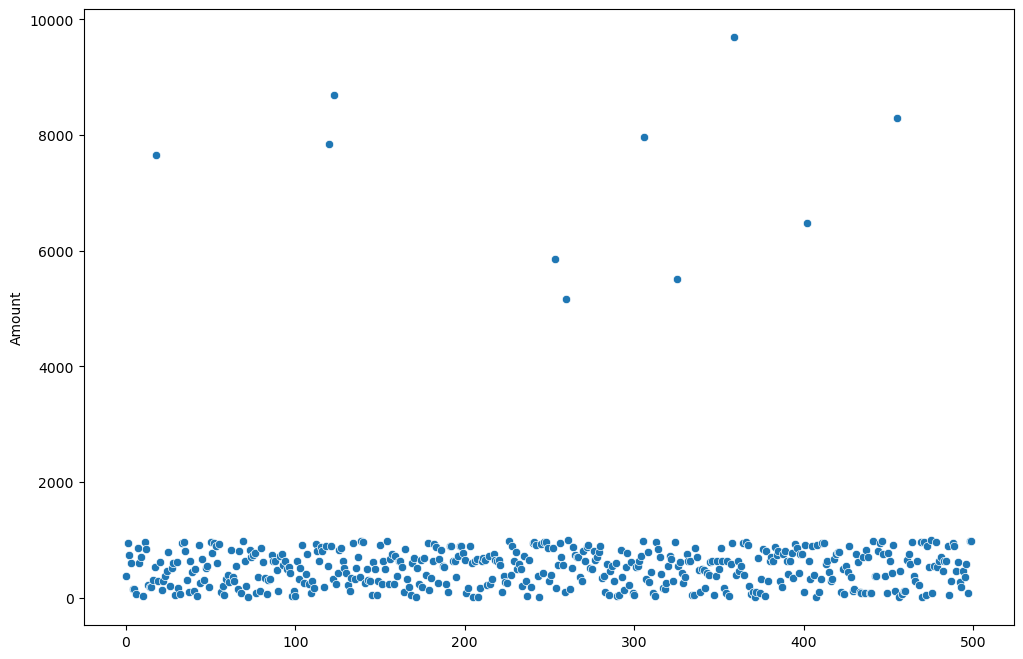

In [17]:
plt.figure(figsize = (12,8))
sns.scatterplot(df["Amount"])
plt.show()

In [18]:
df.head()

,Amount,Time,Location,MerchantCategory,CardHolderAge,IsFraud
0,375.17,47605,Houston,Travel,18.0,0
1,950.76,38088,Los Angeles,Electronics,28.0,0
2,732.26,78752,Miami,Travel,20.0,0
3,599.06,55284,New York,Groceries,69.0,0
4,156.86,57043,New York,Groceries,79.0,0


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


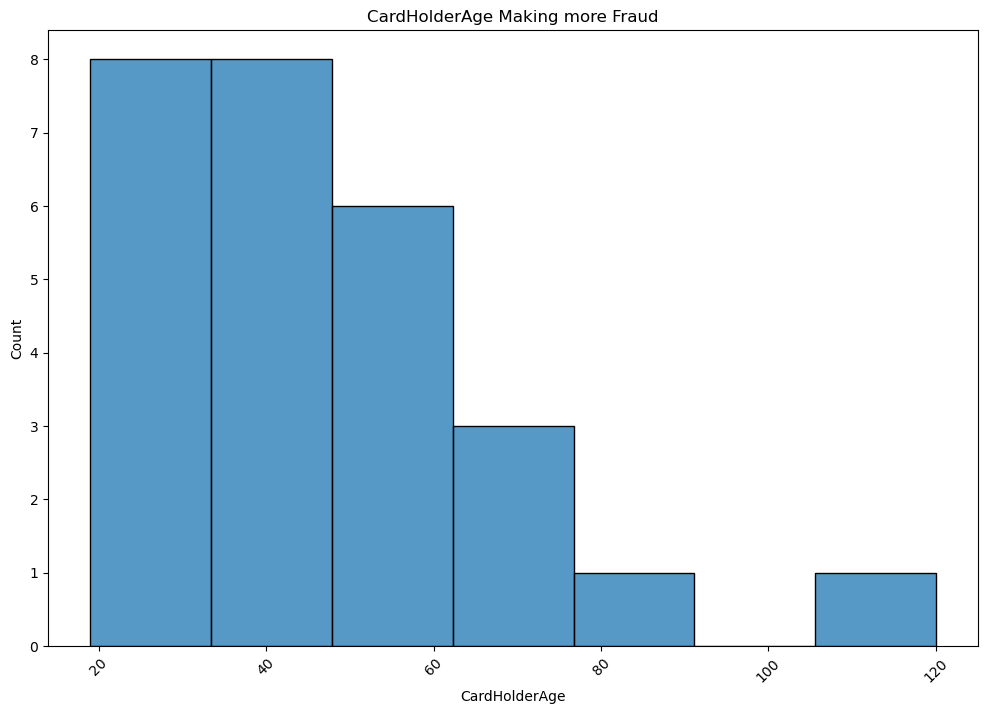

In [96]:
# This graph show 20 to 40 Age CardHolderAge Making more Fraud
plt.figure(figsize = (12,8))
sns.histplot(df[df["IsFraud"] == 1]["CardHolderAge"])
plt.title("CardHolderAge Making more Fraud")
plt.xticks(rotation = 45)
plt.show()

## This graph show 20 to 40 Age CardHolderAge Making more Fraud

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


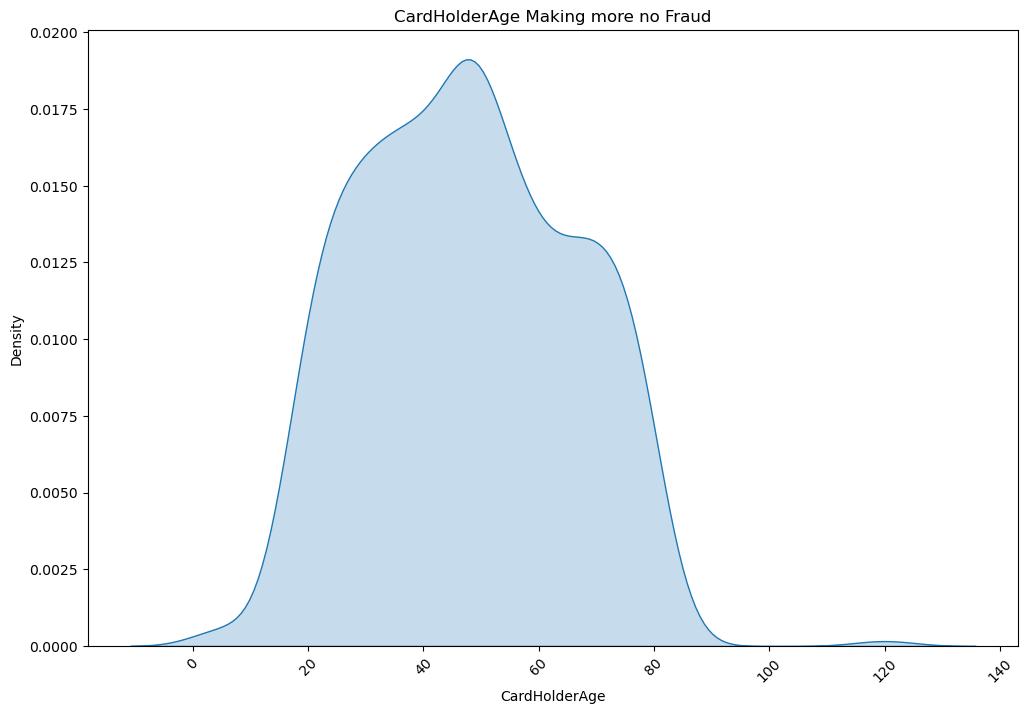

In [95]:
# This graph show CardHolderAge Making more no Fraud
plt.figure(figsize = (12,8))
sns.kdeplot(df[df["IsFraud"] == 0]["CardHolderAge"],fill = True)
plt.title("CardHolderAge Making more no Fraud")
plt.xticks(rotation = 45)
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


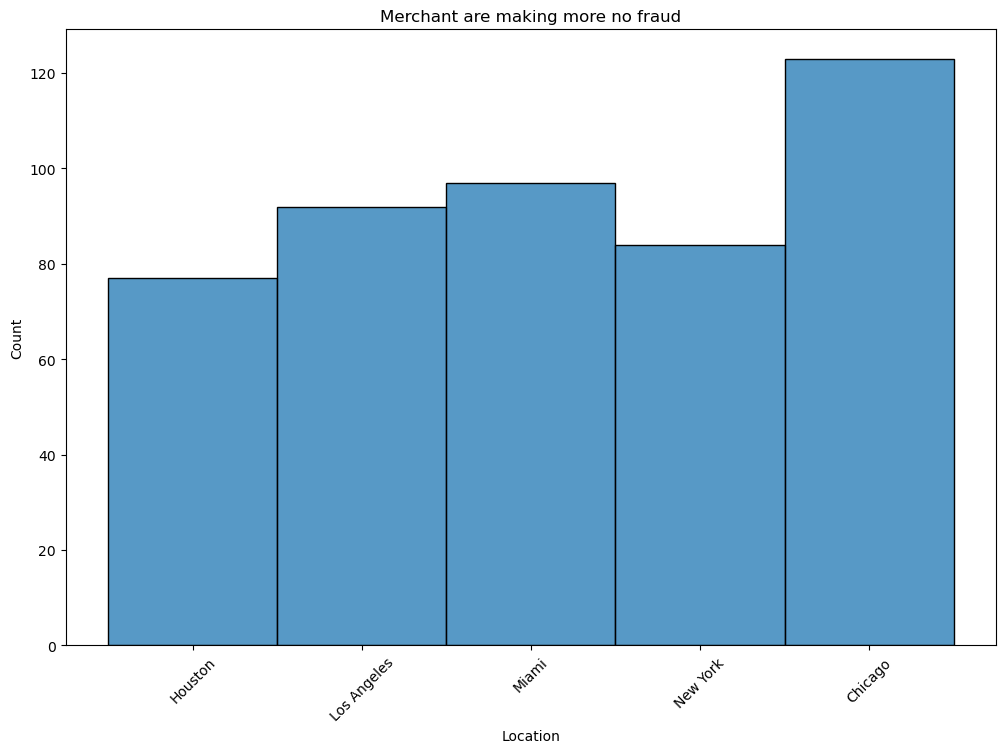

In [94]:
# This graph show the Location merchant are making more no fraud
plt.figure(figsize = (12,8))
sns.histplot(df[df["IsFraud"] == 0]["Location"],fill = True)
plt.title("Merchant are making more no fraud")
plt.xticks(rotation = 45)
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


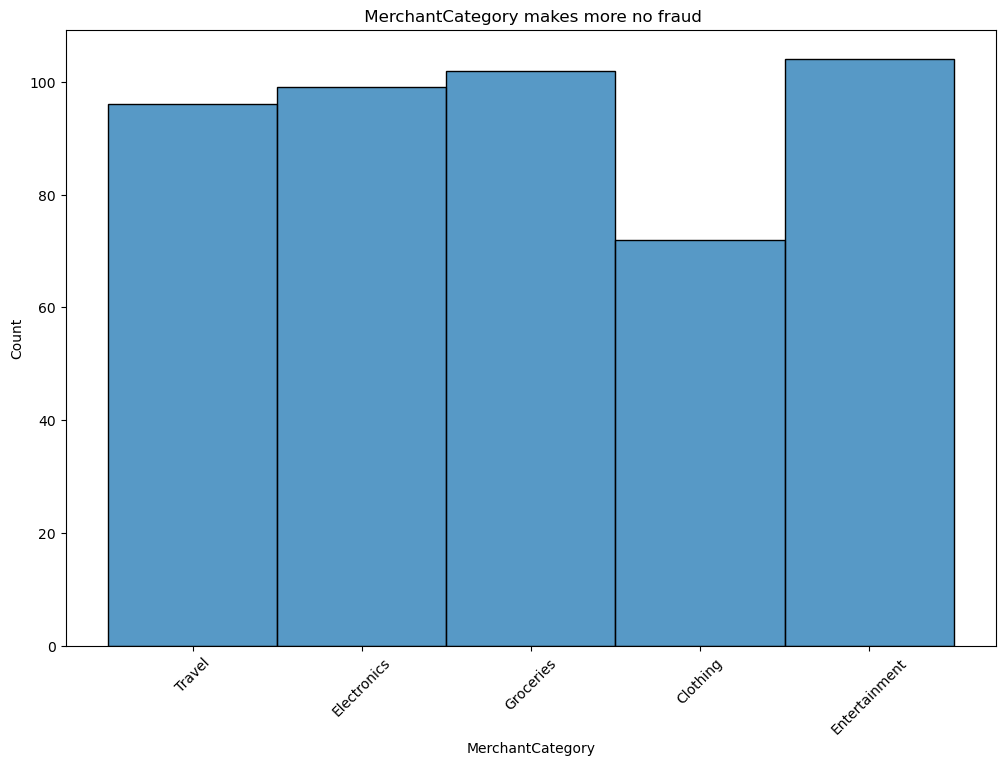

In [92]:
# It check the who MerchantCategory makes more no fraud
plt.figure(figsize = (12,8))
sns.histplot(df[df["IsFraud"] == 0]["MerchantCategory"])
plt.title(" MerchantCategory makes more no fraud")
plt.xticks(rotation = 45)
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

<Figure size 1200x800 with 0 Axes>

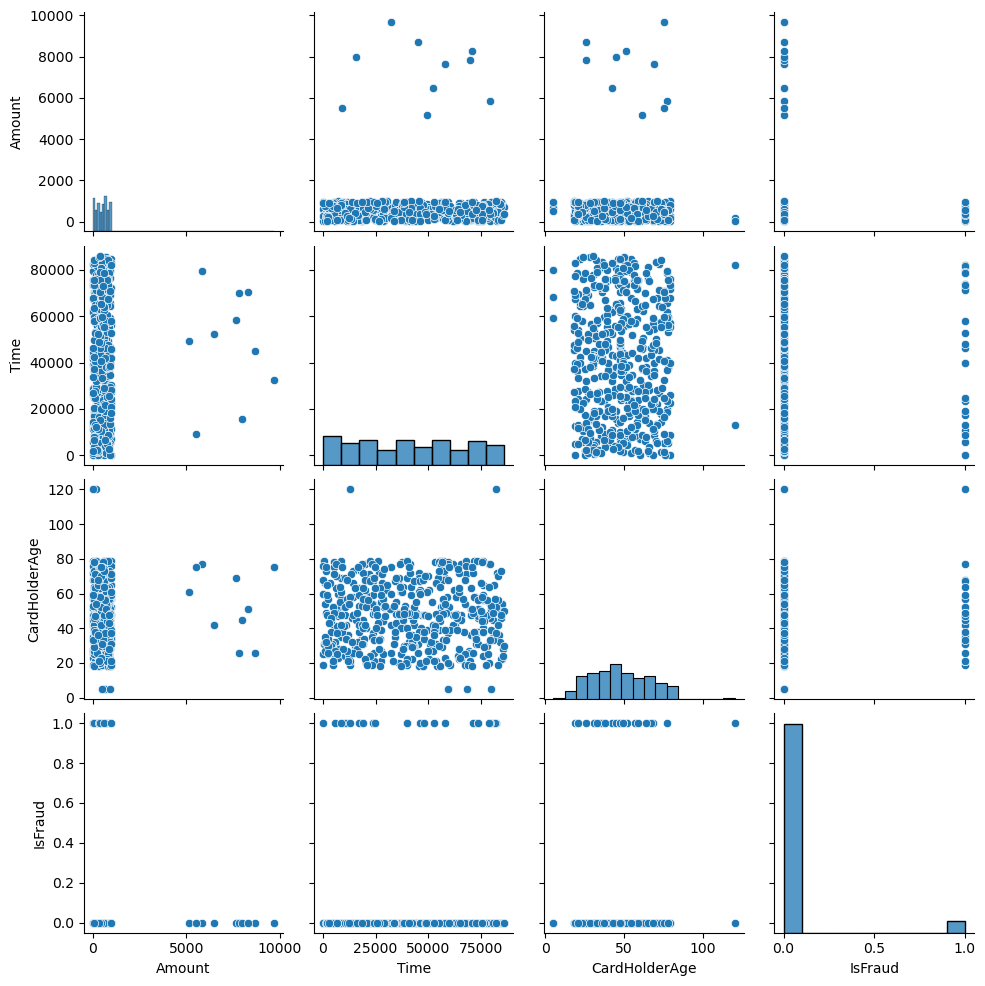

In [91]:
# It check the who MerchantCategory makes more fraud
plt.figure(figsize = (12,8))
sns.pairplot(df)
plt.show()

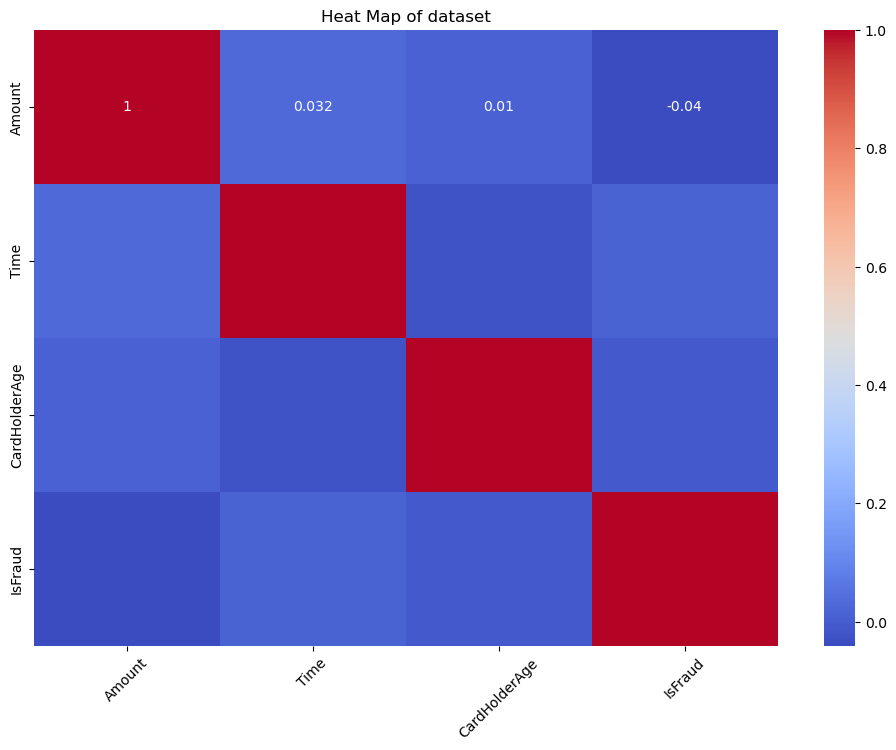

In [20]:
# It show the correlation between all numeric features 
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(numeric_only = True,),annot = True,cmap = "coolwarm" )
plt.title("Heat Map of dataset")
plt.xticks(rotation = 45)
plt.show()

### feature selection 

In [21]:
x = df.drop(columns = ["IsFraud"])
y = df["IsFraud"]

In [22]:
# train_test_split stage for model training
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 4)

### Use pandas get_dummies for making all categories convert in 0 ,1

In [23]:
dummy_train = pd.get_dummies(x_train , columns = ["Location","MerchantCategory"],drop_first = True,sparse = False)
dummy_test = pd.get_dummies(x_test,columns = ["Location","MerchantCategory"],drop_first = True,sparse = False)

In [24]:
# drop the "Time","Amount","CardHolderAge"
dummy_train.drop(columns = ["Time","Amount","CardHolderAge"],inplace = True)
dummy_test.drop(columns = ["Time","Amount","CardHolderAge"],inplace = True)

In [25]:
# select the 'Time', 'Amount', 'CardHolderAge' for concating the final features
x_train_select = x_train[['Amount', 'Time','CardHolderAge']]
x_test_select = x_test[['Amount', 'Time','CardHolderAge']]

### concat the all features with eachother

In [26]:
x_train = pd.concat([x_train_select,dummy_train],axis = 1)
x_test = pd.concat([x_test_select,dummy_test],axis = 1)

In [27]:
x_train.head()

,Amount,Time,CardHolderAge,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,MerchantCategory_Electronics,MerchantCategory_Entertainment,MerchantCategory_Groceries,MerchantCategory_Travel
303,637.79,41832,64.0,False,False,True,False,False,False,False,True
202,162.47,82152,120.0,False,False,True,False,False,False,False,False
349,626.23,10789,34.0,False,False,True,False,False,True,False,False
272,867.21,59383,68.0,True,False,False,False,False,False,False,False
192,900.52,1062,54.0,False,True,False,False,False,False,True,False


### Feature Scaling for convert the big number to -1 to 1 range

In [28]:
std = StandardScaler()

In [29]:
# Scale the Amount feature
x_train["Amount"] = std.fit_transform(x_train[["Amount"]])
x_test["Amount"] = std.transform(x_test[["Amount"]])

In [30]:
# Scale the Time feature
x_train["Time"] = std.fit_transform(x_train[["Time"]])
x_test["Time"] = std.transform(x_test[["Time"]])

In [31]:
# Scale the CardHolderAge feature
x_train["CardHolderAge"] = std.fit_transform(x_train[["CardHolderAge"]])
x_test["CardHolderAge"] = std.transform(x_test[["CardHolderAge"]])

In [32]:
x_train.isnull().sum()

Amount                            0
Time                              0
CardHolderAge                     0
Location_Houston                  0
Location_Los Angeles              0
Location_Miami                    0
Location_New York                 0
MerchantCategory_Electronics      0
MerchantCategory_Entertainment    0
MerchantCategory_Groceries        0
MerchantCategory_Travel           0
dtype: int64

In [33]:
x_train.head()

,Amount,Time,CardHolderAge,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,MerchantCategory_Electronics,MerchantCategory_Entertainment,MerchantCategory_Groceries,MerchantCategory_Travel
303,0.059770,0.055378,0.920581,False,False,True,False,False,False,False,True
202,-0.531998,1.632813,4.014217,False,False,True,False,False,False,False,False
349,0.045378,-1.159114,-0.736724,False,False,True,False,False,True,False,False
272,0.345396,0.742024,1.141555,True,False,False,False,False,False,False,False
192,0.386866,-1.539663,0.368146,False,True,False,False,False,False,True,False


### Replace the True = 1 and False = 0

In [34]:
x_train.replace([True,False],[1,0],inplace = True)
x_test.replace([True,False],[1,0],inplace = True)

## LogisticRegression

In [81]:
# making object of LogisticRegression
lr = LogisticRegression()

In [80]:
# train the model
lr.fit(x_train,y_train)

LogisticRegression()

In [37]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = lr.predict(x_train)
y_pred_test  = lr.predict(x_test)

In [38]:
# check the model overfit or not on training data
print("Accuracy_score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score of test data = ",accuracy_score(y_test,y_pred_test))

Accuracy_score of train data =  0.9375
Accuracy_score of test data =  0.98


## DecisionTreeClassifier

In [39]:
dt = DecisionTreeClassifier()

In [40]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [41]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train_dt = dt.predict(x_train)
y_pred_test_dt = dt.predict(x_test)

In [42]:
# check the model overfit or not on training data
print("Accuracy_score of Decision Tree train data = ",accuracy_score(y_train,y_pred_train_dt))
print("Accuracy_score of Decision Tree test data = ",accuracy_score(y_test,y_pred_test_dt))

Accuracy_score of Decision Tree train data =  1.0
Accuracy_score of Decision Tree test data =  0.89


## GradientBoostingClassifier

In [43]:
gd = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [44]:
gd.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [45]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_gd_train = gd.predict(x_train)
y_pred_gd_test = gd.predict(x_test)

In [46]:
# check the model overfit or not on training data
print("Accuracy_score of Gradient Boosting on train data = ",accuracy_score(y_train,y_pred_gd_train))
print("Accuracy_score of Gradient Boosting on test data = ",accuracy_score(y_test,y_pred_gd_test))

Accuracy_score of Gradient Boosting on train data =  0.995
Accuracy_score of Gradient Boosting on test data =  0.98


## RandomForestClassifier

In [47]:
rd = RandomForestClassifier()

In [48]:
rd.fit(x_train,y_train)

RandomForestClassifier()

In [49]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = rd.predict(x_train)
y_pred_test = rd.predict(x_test)

In [50]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  1.0
Accuracy_score test data =  0.98


##  XGBClassifier 

In [51]:
xgb = XGBClassifier()

In [52]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [53]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = xgb.predict(x_train)
y_pred_test = xgb.predict(x_test)

In [54]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  1.0
Accuracy_score test data =  0.97


## LightGBM 

In [55]:
lgbm = LGBMClassifier()

In [56]:
lgbm.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25, number of negative: 375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062500 -> initscore=-2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMClassifier()

In [57]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = lgbm.predict(x_train)
y_pred_test = lgbm.predict(x_test)

In [58]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  1.0
Accuracy_score test data =  0.98


## CatBoostClassifier

In [59]:
cat = CatBoostClassifier()

In [60]:
cat.fit(x_train,y_train)

Learning rate set to 0.006966
0:	learn: 0.6849676	total: 140ms	remaining: 2m 20s
1:	learn: 0.6768111	total: 144ms	remaining: 1m 11s
2:	learn: 0.6689429	total: 146ms	remaining: 48.5s
3:	learn: 0.6607123	total: 149ms	remaining: 37.2s
4:	learn: 0.6530041	total: 156ms	remaining: 31.1s
5:	learn: 0.6454591	total: 162ms	remaining: 26.8s
6:	learn: 0.6378087	total: 168ms	remaining: 23.8s
7:	learn: 0.6305674	total: 171ms	remaining: 21.2s
8:	learn: 0.6233933	total: 174ms	remaining: 19.2s
9:	learn: 0.6164238	total: 176ms	remaining: 17.4s
10:	learn: 0.6096110	total: 180ms	remaining: 16.1s
11:	learn: 0.6024121	total: 184ms	remaining: 15.2s
12:	learn: 0.5959961	total: 187ms	remaining: 14.2s
13:	learn: 0.5893299	total: 191ms	remaining: 13.4s
14:	learn: 0.5830957	total: 198ms	remaining: 13s
15:	learn: 0.5768202	total: 200ms	remaining: 12.3s
16:	learn: 0.5705280	total: 203ms	remaining: 11.7s
17:	learn: 0.5641594	total: 209ms	remaining: 11.4s
18:	learn: 0.5581609	total: 212ms	remaining: 11s
19:	learn: 0.

In [61]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = cat.predict(x_train)
y_pred_test = cat.predict(x_test)

In [62]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  0.9575
Accuracy_score test data =  0.98


## Gaussian Naive_bayes

In [63]:
gnb = GaussianNB()

In [64]:
gnb.fit(x_train,y_train)

GaussianNB()

In [65]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = gnb.predict(x_train)
y_pred_test = gnb.predict(x_test)

In [66]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  0.9375
Accuracy_score test data =  0.98


## Bernoulli Naive_bayes

In [67]:
bnb = BernoulliNB()

In [68]:
bnb.fit(x_train,y_train)

BernoulliNB()

In [69]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = bnb.predict(x_train)
y_pred_test = bnb.predict(x_test)

In [70]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  0.9375
Accuracy_score test data =  0.98


## Support Vector Machine

In [71]:
svc = SVC()

In [72]:
svc.fit(x_train,y_train)

SVC()

In [73]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = svc.predict(x_train)
y_pred_test = svc.predict(x_test)

In [74]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  0.9375
Accuracy_score test data =  0.98


## VotingClassifier

In [75]:
estimators = [("lr",lr),("dt",dt),("rd",rd),("gd",gd),("xgb",xgb),("lgbm",lgbm),("svc",svc),("bnb",bnb),("gnb",gnb),("cat",cat)]

In [76]:
vot = VotingClassifier(estimators=estimators)

In [77]:
vot.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25, number of negative: 375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062500 -> initscore=-2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()),
                             ('rd', RandomForestClassifier()),
                             ('gd',
                              GradientBoostingClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_...
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('lgbm', LGBMClassifier()), ('svc', SVC()),
                             ('bnb', BernoulliNB()), ('gnb', GaussianNB()),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x000002584FFFFC50>)])

In [78]:
# predict the x_train and x_test because check the overfitting of the model
y_pred_train = vot.predict(x_train)
y_pred_test = vot.predict(x_test)

In [79]:
# check the model overfit or not on training data
print("Accuracy score of train data = ",accuracy_score(y_train,y_pred_train))
print("Accuracy_score test data = ",accuracy_score(y_test,y_pred_test))

Accuracy score of train data =  0.9575
Accuracy_score test data =  0.98
